In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
train_path = r'C:\Users\belen\Documents\Data Science\DataS_Lab5_Tweets\train_clean.csv'
train = pd.read_csv(train_path)

In [3]:
train[['text', 'text_clean', 'target']].head()

,text,text_clean,target
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive u,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,resident ask shelter place notify officer evac...,1
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...,1
4,Just got sent this photo from Ruby #Alaska as ...,get sent photo ruby alaska smoke wildfires pou...,1


In [4]:
X = train['text_clean']
y = train['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

In [5]:
vectorizer = TfidfVectorizer(ngram_range = (1 , 2) )
X_train_tfidf = vectorizer.fit_transform(X_train )
X_test_tfidf = vectorizer.transform(X_test )

In [6]:
modelo_lr = LogisticRegression(random_state = 42 , max_iter= 200 )
modelo_lr.fit(X_train_tfidf, y_train )
y_pred_lr = modelo_lr.predict(X_test_tfidf )

modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_tfidf, y_train )
y_pred_nb = modelo_nb.predict(X_test_tfidf )

modelo_rf = RandomForestClassifier(random_state = 42, n_estimators = 100 )
modelo_rf.fit(X_train_tfidf, y_train )
y_pred_rf = modelo_rf.predict(X_test_tfidf )

In [7]:
resultados_modelos = pd.DataFrame({
    'Modelo': ['LogisticRegression', 'MultinomialNB', 'RandomForestClassifier'],
    'Accuracy': [ accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_rf) ],
    'Precision': [ precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_rf) ] ,
    'Recall': [ recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_rf) ] ,
    'F1-Score': [ f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_rf) ]
})

resultados_modelos = resultados_modelos.sort_values('F1-Score' , ascending= False )
resultados_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.805166,0.834165,0.681957,0.750421
1,MultinomialNB,0.807356,0.863087,0.655454,0.745075
2,RandomForestClassifier,0.791594,0.823303,0.655454,0.729852


In [8]:
mejor_modelo_nombre = resultados_modelos.iloc[0]['Modelo' ]
mejor_modelo_nombre

'LogisticRegression'

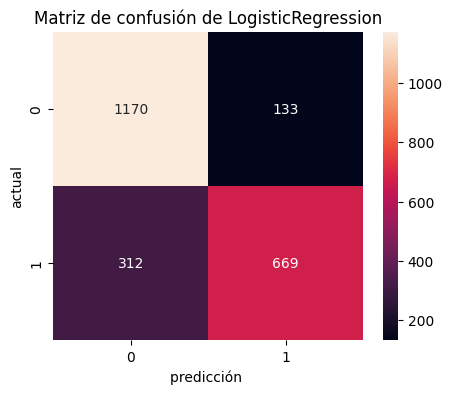

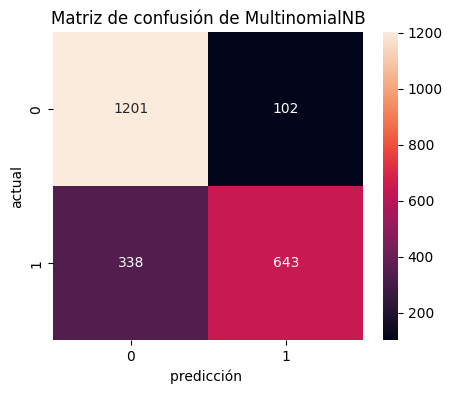

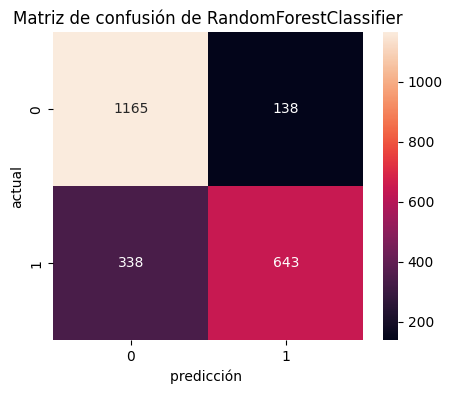

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot = True, fmt = 'd')
plt.title('Matriz de confusión de LogisticRegression')
plt.ylabel('actual')
plt.xlabel('predicción ')
plt.show()

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize = (5 , 4) )
sns.heatmap(cm_nb, annot = True , fmt = 'd' ) 
plt.title('Matriz de confusión de MultinomialNB')
plt.ylabel('actual')
plt.xlabel('predicción ')
plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize = (5 , 4) )
sns.heatmap(cm_rf, annot = True , fmt = 'd')
plt.title('Matriz de confusión de RandomForestClassifier')
plt.ylabel('actual')
plt.xlabel('predicción ')
plt.show()